
Starting GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

===== GridSearchCV Results ===telek
Best parameters found: {'metric': 'euclidean', 'n_neighbors': 26, 'weights': 'distance'}
Best cross-validation accuracy: 0.9040

===== KNN MODEL PERFORMANCE (after GridSearchCV) ===telek
Accuracy: 0.9103

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.71      0.34      0.46       928

    accuracy                           0.91      8238
   macro avg       0.82      0.66      0.71      8238
weighted avg       0.90      0.91      0.90      8238



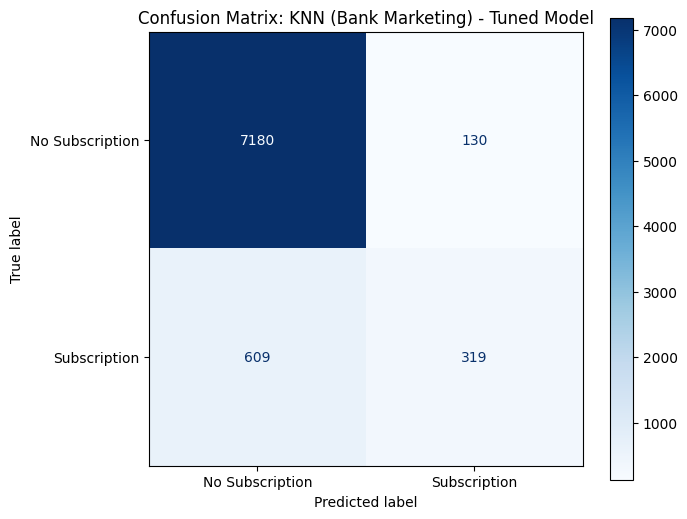

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV # Added GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------- Load Dataset ----------
# Added na_values to handle various representations of missing data more robustly
df = pd.read_csv("/content/sample_data/bank.csv", sep=';', engine='python', on_bad_lines='warn',
                 na_values=['unknown', '?', 'N/A', 'NA', 'None', '-'])

# ---------- Data Preprocessing ----------
# Encode categorical variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Handle missing values by dropping rows with NaNs
# This is crucial as KNeighborsClassifier does not accept missing values
df.dropna(inplace=True)

# ---------- Features and Target ----------
X = df.drop("y", axis=1)
y = df["y"]

# ---------- Train-Test Split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- Feature Scaling (MANDATORY for KNN) ----------
symmetric_scaler = StandardScaler()
X_train_scaled = symmetric_scaler.fit_transform(X_train)
X_test_scaled = symmetric_scaler.transform(X_test)

# ---------- Hyperparameter Tuning with GridSearchCV ----------
# Define the parameter grid for KNN
param_grid = {
    'n_neighbors': list(range(1, 31)), # Explore K from 1 to 30
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'] # Common distance metrics
}

# Initialize KNeighborsClassifier
knn_base = KNeighborsClassifier()

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='accuracy' to optimize for accuracy
# n_jobs=-1 to use all available processors
# verbose=1 to show progress
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the scaled training data
print("\nStarting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("\n===== GridSearchCV Results ===telek")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# The best estimator from GridSearchCV is our final model
knn_final = grid_search.best_estimator_

# ---------- Prediction ----------
y_pred = knn_final.predict(X_test_scaled)

# ---------- Model Evaluation ----------
print("\n===== KNN MODEL PERFORMANCE (after GridSearchCV) ===telek")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------- Confusion Matrix ----------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Subscription", "Subscription"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix: KNN (Bank Marketing) - Tuned Model")
plt.show()